## Importing the Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import regex as re

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import  ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.express as px

from pycaret.regression import *

import shap

import joblib
import json
import warnings
warnings.filterwarnings('ignore')

## Load and Prepare Data

In [3]:
df = pd.read_csv("../data/tehranhouses.csv")
pd.set_option('display.float_format', lambda x: '%.f' % x)
df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price
0,63,1,True,True,True,Shahran,8325000000
1,60,1,True,True,True,Shahran,8325000000
2,79,2,True,True,True,Pardis,2475000000
3,95,2,True,True,True,Shahrake Qods,4061250000
4,123,2,True,True,True,Shahrake Gharb,31500000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3479 entries, 0 to 3478
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Area       3479 non-null   int64  
 1   Room       3479 non-null   int64  
 2   Parking    3479 non-null   bool   
 3   Warehouse  3479 non-null   bool   
 4   Elevator   3479 non-null   bool   
 5   Address    3456 non-null   object 
 6   Price      3479 non-null   float64
dtypes: bool(3), float64(1), int64(2), object(1)
memory usage: 119.0+ KB


In [5]:
df.describe()

,Area,Room,Price
count,3479,3479,3479
mean,8744000,2,24115602341
std,316726629,1,36449706031
min,30,0,16200000
25%,69,2,6382125000
50%,90,2,13050000000
75%,120,2,27000000000
max,16160000000,5,415800000000


In [6]:
print(df.dtypes)
df.shape

Area           int64
Room           int64
Parking         bool
Warehouse       bool
Elevator        bool
Address       object
Price        float64
dtype: object


(3479, 7)

## Visualization

In [ ]:
fig = px.histogram(df, x='Price', nbins=50, title='House Price Distribution')
fig.show()

In [ ]:
fig = px.scatter(df, x='Area', y='Price', title='Area & Price', opacity=0.6)
fig.show()

In [30]:
fig = px.scatter(df, x='Room', y='Price', title='Room & Price', opacity=0.8)
fig.show()

In [ ]:
corr_matrix = df.select_dtypes(include=['float64', 'int64']).corr()
fig = px.imshow(corr_matrix, text_auto=True, aspect="auto", title='Correlation Matrix')
fig.show()

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(18,6))

colors = [['#ADEFD1FF', '#00203FFF'], ['#97BC62FF', '#2C5F2D'], ['#F5C7B8FF', '#FFA177FF']]
explode = [0, 0.2]
columns = ['Parking', 'Warehouse', 'Elevator']
for i in range(3):
        data = df[columns[i]].value_counts()
        ax[i].pie(data, labels=data.values, explode=explode, colors=colors[i], shadow=True)
        ax[i].legend(labels=data.index, fontsize='large')
        ax[i].set_title('{} distribution'.format(columns[i]))

In [ ]:
fig = make_subplots(rows=3, cols=1, subplot_titles=("Area", "Room", "Price"))

fig.add_trace(go.Box(x=df['Area'], name="Area"), row=1, col=1)
fig.add_trace(go.Box(x=df["Room"], name="Room"), row=2, col=1)
fig.add_trace(go.Box(x=df["Price"], name="Price"), row=3, col=1)

fig.update_layout(height=700, title_text="Checking Diffrent Disterbutions")
fig.show()


In [ ]:
df.sort_values("Price" , ascending=False)["Address"].head(10)

In [ ]:
df.Address.value_counts().head(10)

## Preprocessing

In [7]:
df.isnull().sum()

Area          0
Room          0
Parking       0
Warehouse     0
Elevator      0
Address      23
Price         0
dtype: int64

In [8]:
df.dropna(inplace=True)

In [9]:
lower_bound = df['Price'].quantile(0.01)
upper_bound = df['Price'].quantile(0.99)

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

lower_bound = df['Area'].quantile(0.01)
upper_bound = df['Area'].quantile(0.99)

df_clean = df[(df['Area'] >= lower_bound) & (df['Area'] <= upper_bound)]

In [10]:
neighborhood_mean_price = df_clean.groupby('Address')['Price'].mean()
df_clean['Address_Encoded'] = df_clean['Address'].map(neighborhood_mean_price)

global_mean_price = df_clean['Address_Encoded'].mean()

address_mapping = neighborhood_mean_price.to_dict()
address_mapping['UNKNOWN_DEFAULT'] = global_mean_price

with open('../data/address_mapping.json', 'w', encoding='utf-8') as f:
    json.dump(address_mapping, f, ensure_ascii=False, indent=4)

df_clean = df_clean.drop('Address', axis=1)

In [11]:
df_clean[["Parking" , "Warehouse" , "Elevator"]] = df_clean[["Parking" , "Warehouse" , "Elevator"]].astype("int64")
df_clean.sample(5)

,Area,Room,Parking,Warehouse,Elevator,Price,Address_Encoded
1835,60,2,1,1,1,12825000000,13975851724
901,110,3,1,1,1,10485000000,7866450000
2334,200,2,0,0,0,11925000000,4869984375
1939,79,2,1,1,1,13275000000,13435892308
2341,53,2,1,1,0,4950000000,7866450000


In [12]:
X = df_clean.drop(columns = 'Price')
y = df_clean['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)
print(f"shape of x train: {X_train.shape}")
print(f"shape of y train: {y_train.shape}")
print(f"shape of x test: {X_test.shape}")
print(f"shape of y train: {y_test.shape}")

shape of x train: (2671, 6)
shape of y train: (2671,)
shape of x test: (668, 6)
shape of y train: (668,)


## Baseline Modeling with PyCaret

In [13]:
reg_setup = setup(data=df_clean, target='Price', session_id=100)

,Description,Value
0,Session id,100
1,Target,Price
2,Target type,Regression
3,Original data shape,"(3339, 7)"
4,Transformed data shape,"(3339, 7)"
5,Transformed train set shape,"(2337, 7)"
6,Transformed test set shape,"(1002, 7)"
7,Numeric features,6
8,Preprocess,True
9,Imputation type,simple


In [14]:
best_model = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,4477619246.9024,87548401199686533120.0000,9295208530.7177,0.8737,0.3344,0.2736,0.1120
catboost,CatBoost Regressor,4400949819.6952,88216493289920266240.0000,9348664284.4837,0.8733,0.3320,0.2658,0.3160
rf,Random Forest Regressor,4496227208.0067,90713285209570934784.0000,9478898406.2708,0.8684,0.3271,0.2575,0.0400
gbr,Gradient Boosting Regressor,4679776856.0596,92098365739778605056.0000,9534313267.9528,0.8681,0.3516,0.2941,0.0180
et,Extra Trees Regressor,4570833837.9676,98960617210639581184.0000,9907721612.3428,0.8545,0.3396,0.2597,0.0350
xgboost,Extreme Gradient Boosting,4603503206.4000,102164790865597300736.0000,10034108876.8000,0.8515,0.3432,0.2565,0.2430
knn,K Neighbors Regressor,5105610060.8000,123610653894791446528.0000,10970906368.0000,0.8201,0.3730,0.2859,0.0090
ada,AdaBoost Regressor,7429971405.7707,124865939390997118976.0000,11156135040.1903,0.8195,0.6277,0.7605,0.0100
dt,Decision Tree Regressor,5275396575.7116,136964955092449263616.0000,11657533480.1038,0.8009,0.3991,0.2977,0.0070
lr,Linear Regression,6972468336.6059,142985533435863465984.0000,11914482536.3029,0.7945,0.8078,0.6285,0.2740


## Fine Tuning Models

In [15]:
lgbm = create_model('lightgbm')
tuned_lgbm = tune_model(lgbm, optimize='R2', n_iter=30)

evaluate_model(tuned_lgbm)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4611768210.3627,74432266105361137664.0000,8627413639.4032,0.9246,0.3505,0.2688
1,3855407394.1014,62818561463005569024.0000,7925816138.6072,0.8679,0.2949,0.2373
2,4765858213.0025,97519219217327095808.0000,9875181984.0106,0.8365,0.3555,0.3026
3,4669634635.8749,75262826497481146368.0000,8675415061.9715,0.8989,0.3661,0.3010
4,5106452735.7357,133169236928187908096.0000,11539897613.4188,0.8165,0.3174,0.2256
5,4262920548.3930,66464607957235458048.0000,8152582900.9729,0.8882,0.2993,0.2346
6,3839395147.0986,73562833185262125056.0000,8576877822.6848,0.8834,0.3022,0.2378
7,4864449912.0065,97659193314187886592.0000,9882266608.1314,0.8840,0.3355,0.2606
8,4189810609.8186,86361292161822654464.0000,9293077647.4655,0.8992,0.3021,0.2447


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4981736676.2768,85014863817915826176.0000,9220350525.7618,0.9139,0.3619,0.2707
1,3917605630.7664,65808411696259391488.0000,8112238390.0043,0.8616,0.2932,0.2355
2,4764123451.1398,82369031903282053120.0000,9075738642.2969,0.8619,0.3535,0.3016
3,4921521653.6454,82026423653665652736.0000,9056844022.8186,0.8898,0.3846,0.3114
4,5005806855.5316,123959596026062946304.0000,11133714385.8671,0.8292,0.3077,0.2158
5,4528999158.2974,68942900674934464512.0000,8303186176.0974,0.8841,0.3006,0.2395
6,4187649438.2423,81504291989802876928.0000,9027972750.8341,0.8709,0.3128,0.2488
7,5055364894.7811,109736196822009790464.0000,10475504609.4214,0.8696,0.3526,0.2644
8,4326522587.2693,91037316658991562752.0000,9541347738.0814,0.8937,0.3148,0.2565


Fitting 10 folds for each of 30 candidates, totalling 300 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [16]:
gbr = create_model("gbr")
tuned_gbr = tune_model(gbr, optimize='R2', n_iter=30)

evaluate_model(tuned_gbr)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,5215078349.9666,107837507123270467584.0000,10384483960.3743,0.8907,0.3772,0.3039
1,4272718703.4489,77515298097222811648.0000,8804277261.4919,0.8370,0.3607,0.3214
2,4857851086.6729,92310530185265512448.0000,9607836915.0015,0.8452,0.3991,0.3248
3,4760049130.1804,77222705138003132416.0000,8787645027.9926,0.8963,0.3764,0.3270
4,5182334225.2448,142925433680096608256.0000,11955142562.0984,0.8031,0.3268,0.2360
5,4717776397.7647,81145783565641433088.0000,9008095446.0775,0.8635,0.3104,0.2563
6,3878129533.7075,61870991126050029568.0000,7865811536.3928,0.9020,0.3016,0.2483
7,5082946285.1926,110554744248585371648.0000,10514501616.7475,0.8686,0.3477,0.2718
8,4358260891.2093,87349406754478014464.0000,9346090452.9369,0.8980,0.3072,0.2536


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4940031930.0324,105261111454107303936.0000,10259683789.1870,0.8933,0.3527,0.2704
1,3996694135.8187,66948916107486945280.0000,8182231731.4708,0.8592,0.3136,0.2605
2,4748518965.8113,98316895392013729792.0000,9915487652.7589,0.8351,0.3595,0.3026
3,4671733118.6119,73690285271073300480.0000,8584304588.6707,0.9010,0.3829,0.3296
4,4902805272.4412,138932698335661424640.0000,11786971550.6427,0.8086,0.3134,0.2200
5,4659319163.2239,91735318382665351168.0000,9577855625.4866,0.8457,0.3123,0.2504
6,3647732651.5582,65783102996092780544.0000,8110678331.4402,0.8958,0.2924,0.2298
7,4867171514.1905,97169993057767161856.0000,9857484114.0002,0.8845,0.3451,0.2713
8,4216183864.1776,95338478091106205696.0000,9764142465.7318,0.8887,0.2975,0.2485


Fitting 10 folds for each of 30 candidates, totalling 300 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [17]:
catboost = create_model("catboost")
tuned_catboost = tune_model(catboost, optimize='R2', n_iter=30)

evaluate_model(tuned_catboost)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4735163801.1536,104650304440512233472.0000,10229873139.0234,0.8940,0.3536,0.2671
1,3968234488.4384,72748766827758845952.0000,8529288764.4726,0.8470,0.2911,0.2351
2,4542626299.8039,83290712556587810816.0000,9126374557.1058,0.8603,0.3643,0.2838
3,4600921746.8594,69532929271269801984.0000,8338640732.8335,0.9066,0.3686,0.3069
4,4865991803.2114,129557588730695827456.0000,11382336699.0568,0.8215,0.3264,0.2304
5,4730249443.2603,88085157335052566528.0000,9385369323.3166,0.8519,0.3135,0.2518
6,3539223426.8511,68243756978806136832.0000,8260977967.4568,0.8919,0.2754,0.2131
7,4585084563.5317,84672618583556423680.0000,9201772578.3436,0.8994,0.3452,0.2647
8,4210601144.8871,97741274784674185216.0000,9886418703.6901,0.8859,0.2913,0.2391


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,20015705691.1092,991039688190423203840.0000,31480782839.5423,-0.0042,1.1980,2.0862
1,15009936376.8902,478889508944729538560.0000,21883544250.0690,-0.0071,1.0644,1.8078
2,17217780783.9467,595985017964646236160.0000,24412804385.4991,0.0006,1.2122,2.2923
3,17580185807.4651,743689304210430099456.0000,27270667469.1037,0.0013,1.1687,2.0736
4,17353455409.3427,724930650457153863680.0000,26924536216.1942,0.0011,1.1088,1.8753
5,16880326114.8625,595863564078037598208.0000,24410316754.9714,-0.0020,1.0811,1.7641
6,17316814532.2871,633895838057714286592.0000,25177288139.4664,-0.0044,1.1810,2.1828
7,18758550959.2932,845496765604180656128.0000,29077427080.1971,-0.0046,1.1543,1.9472
8,18233224725.9532,855499118177764769792.0000,29248916529.9805,0.0012,1.2222,2.2926


Fitting 10 folds for each of 30 candidates, totalling 300 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [18]:
rf = create_model('rf')
tuned_rf = tune_model(rf, optimize='R2', n_iter=30)

evaluate_model(tuned_rf)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4887746071.9853,93251101349599166464.0000,9656660983.4662,0.9055,0.3449,0.2559
1,3955556903.2702,79081157274059997184.0000,8892758698.7425,0.8337,0.2646,0.2068
2,4479445462.0579,85867617082285178880.0000,9266478138.0137,0.8560,0.3234,0.2615
3,4828355155.2404,87272400228065755136.0000,9341969825.9021,0.8828,0.3689,0.3032
4,4770108398.4993,133094572149078261760.0000,11536662088.7100,0.8166,0.3186,0.2044
5,4943411906.7020,107905263560815443968.0000,10387745836.3600,0.8185,0.3224,0.2502
6,3815541790.4172,60062940403696885760.0000,7750028413.0896,0.9048,0.3061,0.2304
7,4798285134.1831,87012747653216911360.0000,9328062373.9991,0.8966,0.3316,0.2532
8,4111116212.0277,90335726651675492352.0000,9504510858.0966,0.8945,0.2799,0.2221


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4778586869.9298,90263431686304694272.0000,9500706904.5574,0.9085,0.3410,0.2475
1,3771457161.2015,59565766955290435584.0000,7717886171.4391,0.8747,0.2821,0.2237
2,4400743385.0113,79718569282426224640.0000,8928525593.9839,0.8663,0.3411,0.2745
3,4578851311.9609,82214215082875174912.0000,9067205472.6291,0.8896,0.3596,0.2908
4,4902015691.4781,125070350723468967936.0000,11183485624.9503,0.8277,0.3099,0.2073
5,3948340683.0339,61521232739247202304.0000,7843547203.8643,0.8965,0.2893,0.2178
6,3581521311.6379,70038522128396361728.0000,8368902086.1996,0.8890,0.2852,0.2106
7,4499779111.2149,83117952572126674944.0000,9116904769.2803,0.9012,0.3305,0.2498
8,4145215450.1951,89090350152063057920.0000,9438768465.8573,0.8960,0.2863,0.2257


Fitting 10 folds for each of 30 candidates, totalling 300 fits


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

## Explainability

In [19]:
explainer_lgbm = shap.Explainer(lgbm, X_train)
shap_values_lgbm = explainer_lgbm(X_train)

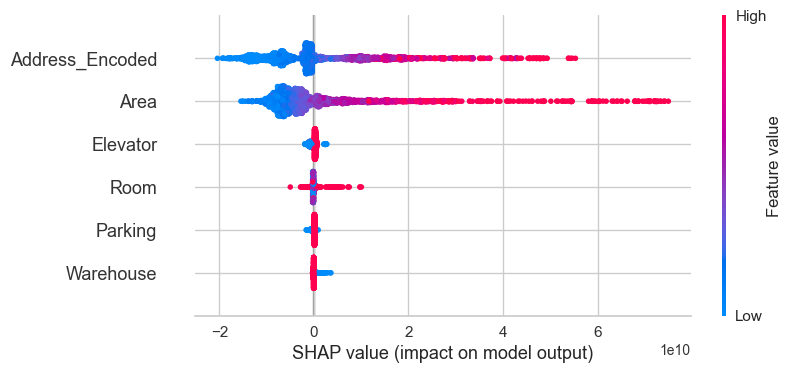

In [20]:
shap.plots.beeswarm(shap_values_lgbm)

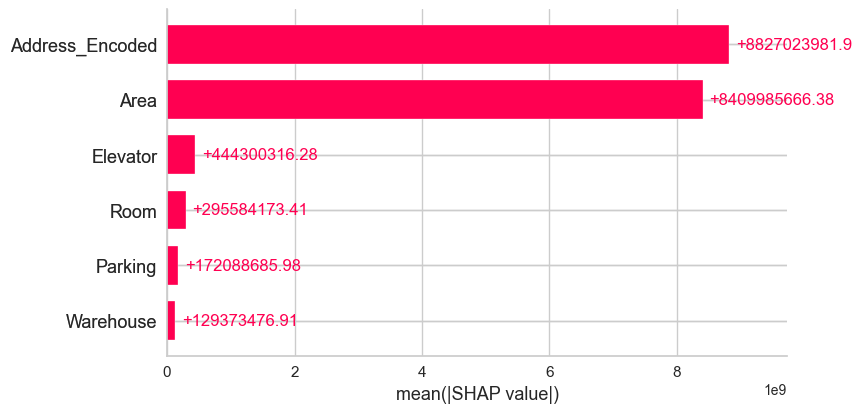

In [21]:
shap.plots.bar(shap_values_lgbm)

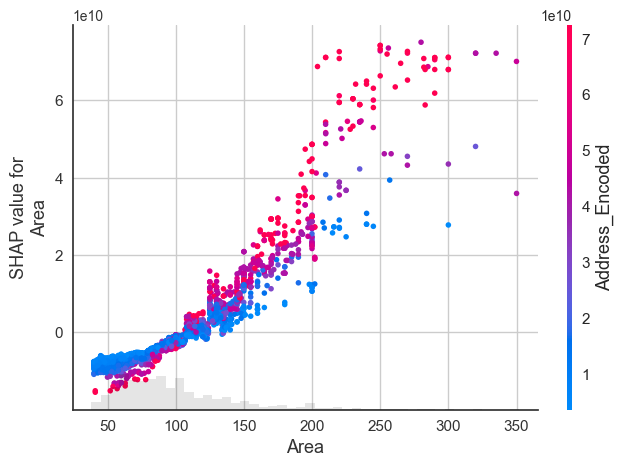

In [22]:
shap.plots.scatter(shap_values_lgbm[:, "Area"], color=shap_values_lgbm)

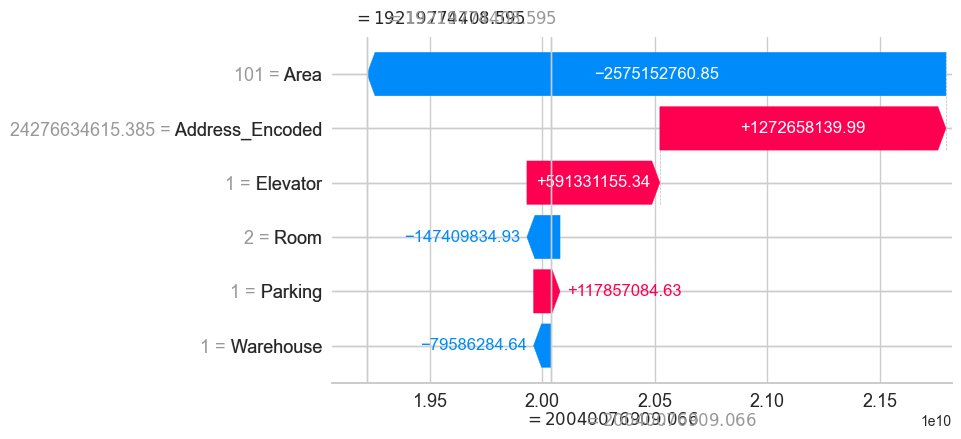

In [23]:
shap.plots.waterfall(shap_values_lgbm[65])

 99%|===================| 2645/2671 [00:44<00:00]        

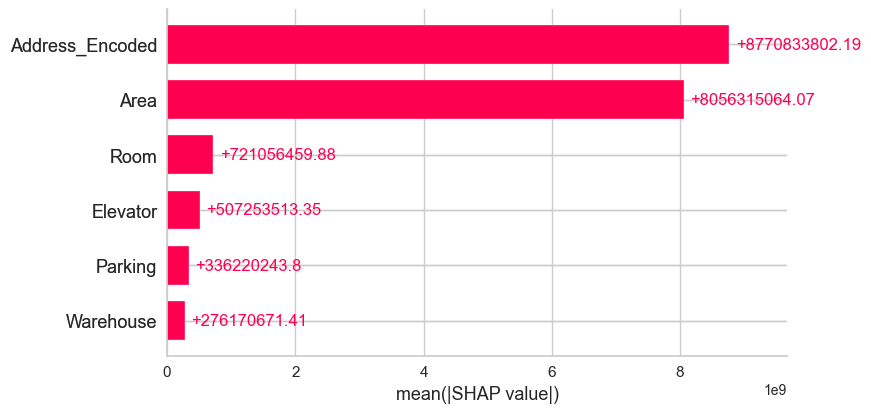

In [24]:
explainer_catboost = shap.Explainer(catboost, X_train)
shap_values_catboost = explainer_catboost(X_train)
shap.plots.bar(shap_values_catboost)

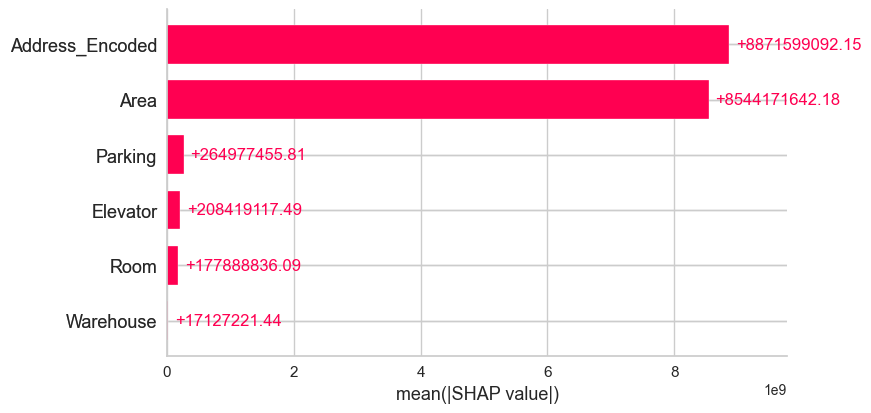

In [25]:
explainer_gbr = shap.Explainer(gbr, X_train)
shap_values_gbr = explainer_gbr(X_train)
shap.plots.bar(shap_values_gbr)

 98%|===================| 2606/2671 [00:31<00:00]        

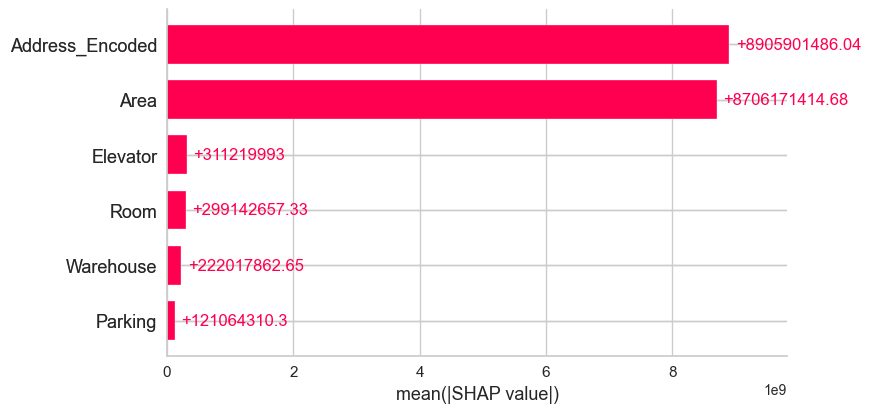

In [26]:
explainer_rf = shap.Explainer(rf, X_train)
shap_values_rf = explainer_rf(X_train)
shap.plots.bar(shap_values_rf)

## Saving Final Model

In [28]:
blender = blend_models(estimator_list=[lgbm, catboost, rf])
final_model = finalize_model(blender)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,4611682017.4343,85997429311840763904.0000,9273479892.2433,0.9129,0.3413,0.2532
1,3806984179.9435,68637156210921332736.0000,8284754444.8174,0.8557,0.2755,0.2172
2,4404211265.9052,84894394922428940288.0000,9213815437.8319,0.8576,0.3320,0.2723
3,4577503328.1611,73791077376815759360.0000,8590173303.0723,0.9009,0.3617,0.2959
4,4808222551.1342,127741025138012569600.0000,11302257523.9645,0.8240,0.3118,0.2128
5,4459714046.6227,81970944804229316608.0000,9053780691.1936,0.8622,0.3034,0.2355
6,3573864495.9094,62894864221173104640.0000,7930628236.2227,0.9003,0.2816,0.2167
7,4610204731.4410,84815836490906828800.0000,9209551372.9447,0.8992,0.3311,0.2518
8,4079400942.6541,86108422772314619904.0000,9279462418.2824,0.8995,0.2836,0.2286


In [29]:
save_model(final_model, '../models/tehran_house_price_pipeline')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['Area', 'Room', 'Parking',
                                              'Warehouse', 'Elevator',
                                              'Address_Encoded'],
                                     transformer=SimpleImputer())),
                 ('categorical_imputer',
                  TransformerWrapper(include=[],
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('actual_estimator',
                  VotingRegressor(estimators=[('Light Gradient Boosting Machine',
                                               LGBMRegressor(n_jobs=-1,
                                                             random_state=100)),
                                              ('CatBoost Regressor',
                                               CatBoostRegressor(border_count=254, loss_function='RMSE', random_state=1